## Objective
Use Polars and multithreading to perform fast, parallel analysis of taxi trip data. The goal is to compute multiple key performance metrics simultaneously for different passenger groups to help the operations team make decisions.

## Problem Statement
The operations team wants answers to these questions:
1. How much revenue is generated by trips for 1, 2, 3, and 4+ passengers?
2. What is the average tip amount and maximum tip for each passenger group?
3. How many trips occur per passenger group?

The dataset is large (hundreds of thousands of rows or more). Traditional row-wise processing is too slow, so parallel computation is needed to produce insights quickly.

In [1]:
import polars as pl
from concurrent.futures import ThreadPoolExecutor
import time
import matplotlib.pyplot as plt

In [ ]:
## Data Source to be downloaded from the link below and placed in the `data` directory:
# https://github.com/DataTalksClub/nyc-tlc-data/releases/tag/yellow

# Load data
df = pl.read_csv(
    "../data/yellow_tripdata_2019-05.csv.gz",
    try_parse_dates=True,
    null_values=["", "NA"]
)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset shape: 7,565,261 rows × 18 columns


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
i64,datetime[μs],datetime[μs],i64,f64,i64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
1,2019-05-01 00:14:50,2019-05-01 00:16:48,1,0.0,1,"""N""",145,145,2,3.0,0.5,0.5,0.0,0.0,0.3,4.3,0.0
1,2019-05-01 00:35:54,2019-05-01 00:37:27,1,1.5,1,"""N""",145,145,2,3.0,0.5,0.5,0.0,0.0,0.3,4.3,0.0
1,2019-05-01 00:37:45,2019-05-01 00:37:49,1,1.5,1,"""N""",145,145,2,2.5,0.5,0.5,0.0,0.0,0.3,3.8,0.0


In [3]:
# Defining passenger groups
GROUPS = {
    "1 passenger":  pl.col("passenger_count") == 1,
    "2 passengers": pl.col("passenger_count") == 2,
    "3 passengers": pl.col("passenger_count") == 3,
    "4+ passengers": pl.col("passenger_count") >= 4,
}

print("Defined passenger groups:")
for label in GROUPS:
    print(f" - {label}")

Defined passenger groups:
 - 1 passenger
 - 2 passengers
 - 3 passengers
 - 4+ passengers


In [4]:
# Per-group analysis
def analyze_group(label: str, mask: pl.Expr) -> dict:
    """Compute revenue, tip, and trip-count metrics for a group."""
    subset = df.filter(mask)
    
    metrics = subset.select([
        pl.len().alias("trip_count"),
        pl.col("total_amount").sum().round(2).alias("total_revenue"),
        pl.col("tip_amount").mean().round(4).alias("avg_tip"),
        pl.col("tip_amount").max().round(2).alias("max_tip"),
    ]).to_dicts()[0]          # single-row result → plain dict

    return {"group": label, **metrics}

In [5]:
# Multithreading with ThreadPoolExecutor
start = time.perf_counter()

with ThreadPoolExecutor(max_workers=len(GROUPS)) as pool:
    futures = [
        pool.submit(analyze_group, label, mask)
        for label, mask in GROUPS.items()
    ]
    results = [f.result() for f in futures]

elapsed = time.perf_counter() - start
print(f"Parallel analysis completed in {elapsed:.3f}s\n")

# Display results
summary = (
    pl.DataFrame(results)
    .sort("group")
)

summary

Parallel analysis completed in 0.540s



group,trip_count,total_revenue,avg_tip,max_tip
str,i64,f64,f64,f64
"""1 passenger""",5291162,1.0271e8,2.2695,333.33
"""2 passengers""",1157575,2.3269e7,2.2565,444.0
"""3 passengers""",321528,6338905.6,2.1813,176.0
"""4+ passengers""",651191,1.2696e7,2.2368,298.8


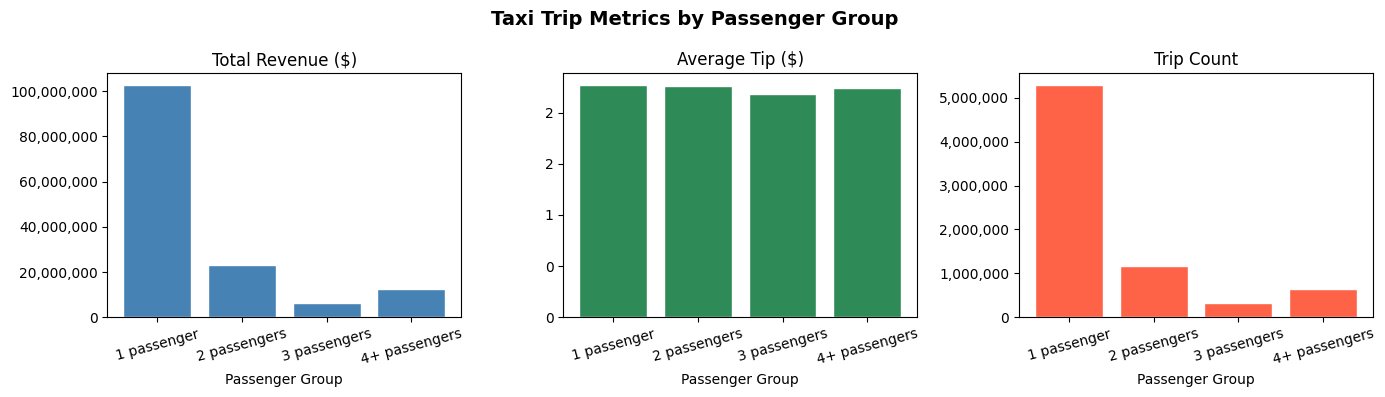

In [6]:
# Quick bar-chart of revenue by group
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Taxi Trip Metrics by Passenger Group", fontsize=14, fontweight="bold")

metrics_to_plot = [
    ("total_revenue", "Total Revenue ($)", "steelblue"),
    ("avg_tip",       "Average Tip ($)",   "seagreen"),
    ("trip_count",    "Trip Count",        "tomato"),
]

for ax, (col, title, color) in zip(axes, metrics_to_plot):
    ax.bar(summary["group"], summary[col], color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Passenger Group")
    ax.tick_params(axis="x", rotation=15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## Answers:

* Single-passenger trips dominate revenue by a wide margin, generating over 4x more than any other group.
* Average tips are remarkably consistent across all groups (all hovering around $2.18–$2.27). The highest single tip recorded was $444.00 from a 2-passenger trip.
* Solo riders account for nearly 70% of all trips. Interestingly, 4+ passenger trips (651K) outnumber 3-passenger trips (321K), suggesting groups of 4 or more are more common than groups of exactly 3.